In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Step1

In [2]:
df = pd.read_csv('../data/adult.csv').replace('?', np.nan)

In [4]:
object_cols =  df.select_dtypes(include=['object','string']).columns

for col in object_cols:
    mode_value = df[col].mode()
    if not mode_value.empty:
        df[col] = df[col].fillna(mode_value[0])

print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [5]:
country_count = df["native-country"].value_counts()

countries_to_replace = country_count[country_count < 40].index

df["native-country"] = df["native-country"].replace(countries_to_replace, "others")

print(df["native-country"].value_counts())

native-country
United-States         29753
Mexico                  643
others                  375
Philippines             198
Germany                 137
Canada                  121
Puerto-Rico             114
El-Salvador             106
India                   100
Cuba                     95
England                  90
Jamaica                  81
South                    80
China                    75
Italy                    73
Dominican-Republic       70
Vietnam                  67
Guatemala                64
Japan                    62
Poland                   60
Columbia                 59
Taiwan                   51
Haiti                    44
Iran                     43
Name: count, dtype: int64


Step2

nominal and  ordinal function

In [6]:
def nominal_binary_encode(df, column_name, drop_original=True):

    df_temp = df.copy()


    unique_values = df_temp[column_name].dropna().unique()


    for value in unique_values:
        col_name = f"{column_name} = {value}"
        df_temp[col_name] = (df_temp[column_name] == value).astype(int)


    if drop_original:
        df_temp = df_temp.drop(column_name, axis=1)

    print(f"✅ {column_name}: {len(unique_values)} binary columns created")

    return df_temp

In [7]:
df = nominal_binary_encode(df,'workclass',True)
df = nominal_binary_encode(df,'education',True)
df = nominal_binary_encode(df,'income',True)
df = nominal_binary_encode(df,'marital-status',True)
df = nominal_binary_encode(df,'occupation',True)
df = nominal_binary_encode(df,'relationship',True)
df = nominal_binary_encode(df,'race',True)
df = nominal_binary_encode(df,'native-country',True)
df = nominal_binary_encode(df,'sex',True)

✅ workclass: 8 binary columns created
✅ education: 16 binary columns created
✅ income: 2 binary columns created
✅ marital-status: 7 binary columns created
✅ occupation: 14 binary columns created
✅ relationship: 6 binary columns created
✅ race: 5 binary columns created
✅ native-country: 24 binary columns created
✅ sex: 2 binary columns created


 numerical column function

In [8]:
def numerical_binary_encode(df, column_name, n_bins=None, custom_bins=None,
            binning_method='equal_width', drop_original=True, prefix_name=None):

    df_temp = df.copy()

    if prefix_name is None:
        prefix_name = column_name


    if custom_bins is not None:

        print(f"✅ custom bins for {column_name}: {custom_bins}")
        bins = sorted(list(set([float('-inf')] + custom_bins + [float('inf')])))

    elif binning_method == 'equal_frequency':

        print(f"✅ equal frequency for {column_name}: {n_bins} bins")
        _, bins = pd.qcut(df_temp[column_name], q=n_bins, retbins=True, duplicates='drop')
        bins[0] = float('-inf')
        bins[-1] = float('inf')

    else:

        print(f"✅ equal width for {column_name}: {n_bins} bins")
        _, bins = pd.cut(df_temp[column_name], bins=n_bins, retbins=True)
        bins[0] = float('-inf')
        bins[-1] = float('inf')


    df_temp['bin'] = pd.cut(df_temp[column_name], bins=bins, labels=False, include_lowest=True)


    labels = {}
    for i in range(len(bins) - 1):
        left, right = bins[i], bins[i + 1]

        if left == float('-inf'):
            name = f'{prefix_name} <= {right:.0f}'
        elif right == float('inf'):
            name = f'{prefix_name} > {left:.0f}'
        else:
            name = f'{left:.0f} < {prefix_name} <= {right:.0f}'

        labels[i] = name

    df_temp['label'] = df_temp['bin'].map(labels)


    dummies = pd.get_dummies(df_temp['label'])


    result = pd.concat([df_temp, dummies], axis=1)

    cols_to_drop = ['bin', 'label']
    if drop_original:
        cols_to_drop.append(column_name)

    result = result.drop(cols_to_drop, axis=1)

    print(f"   created {len(dummies.columns)} bins: {list(dummies.columns)}\n")

    return result


In [9]:
# age
df = numerical_binary_encode(df, 'age', n_bins=12, binning_method='equal_frequency')

# education-num
df = numerical_binary_encode(df, 'education-num', n_bins=8, binning_method='equal_width')

# hours-per-week
df = numerical_binary_encode(df, 'hours-per-week', n_bins=5, binning_method='equal_width')

# capital-gain
df = numerical_binary_encode(df, 'capital-gain', custom_bins=[2000, 5700, 11500, 21500, 64000])

# capital-loss
df = numerical_binary_encode(df, 'capital-loss', custom_bins=[900, 2000, 3100])


✅ equal frequency for age: 12 bins
   created 12 bins: ['21 < age <= 24', '24 < age <= 28', '28 < age <= 31', '31 < age <= 34', '34 < age <= 37', '37 < age <= 40', '40 < age <= 44', '44 < age <= 48', '48 < age <= 52', '52 < age <= 59', 'age <= 21', 'age > 59']

✅ equal width for education-num: 8 bins
   created 8 bins: ['10 < education-num <= 12', '12 < education-num <= 14', '3 < education-num <= 5', '5 < education-num <= 7', '7 < education-num <= 8', '8 < education-num <= 10', 'education-num <= 3', 'education-num > 14']

✅ equal width for hours-per-week: 5 bins
   created 5 bins: ['21 < hours-per-week <= 40', '40 < hours-per-week <= 60', '60 < hours-per-week <= 79', 'hours-per-week <= 21', 'hours-per-week > 79']

✅ custom bins for capital-gain: [2000, 5700, 11500, 21500, 64000]
   created 6 bins: ['11500 < capital-gain <= 21500', '2000 < capital-gain <= 5700', '21500 < capital-gain <= 64000', '5700 < capital-gain <= 11500', 'capital-gain <= 2000', 'capital-gain > 64000']

✅ custom bin

In [10]:
df = df.drop('fnlwgt', axis=1)

In [11]:
df = pd.DataFrame(df)
df.to_csv("../dist/adult_preprocessed.csv",index=False)

In [12]:
preprocessed_data = pd.read_csv("../dist/adult_preprocessed.csv")
preprocessed_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Columns: 119 entries, workclass = State-gov to capital-loss > 3100
dtypes: bool(35), int64(84)
memory usage: 22.0 MB


Step 3

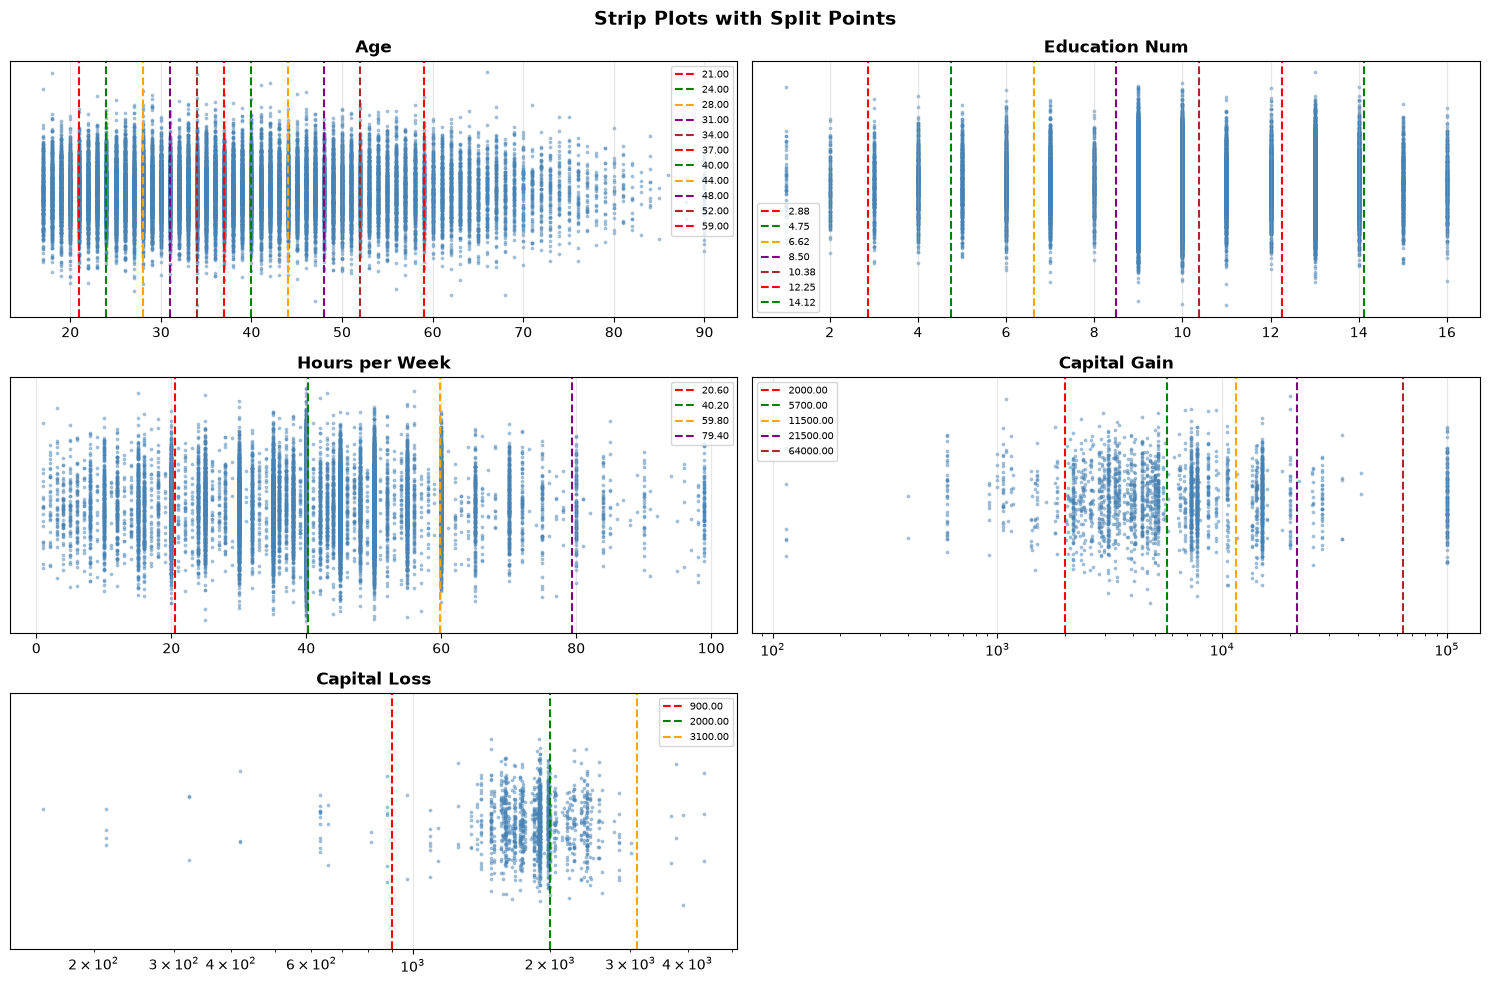

In [13]:
df = pd.read_csv("../data/adult.csv")
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
fig.suptitle('Strip Plots with Split Points', fontsize=14, fontweight='bold')


plots_info = {
    0: {'col': 'age', 'title': 'Age', 'splits': pd.qcut(df['age'], q=12, retbins=True, duplicates='drop')[1][1:-1]},
    1: {'col': 'education-num', 'title': 'Education Num', 'splits': pd.cut(df['education-num'], bins=8, retbins=True)[1][1:-1]},
    2: {'col': 'hours-per-week', 'title': 'Hours per Week', 'splits': pd.cut(df['hours-per-week'], bins=5, retbins=True)[1][1:-1]},
    3: {'col': 'capital-gain', 'title': 'Capital Gain', 'splits': [2000, 5700, 11500, 21500, 64000], 'log': True},
    4: {'col': 'capital-loss', 'title': 'Capital Loss', 'splits': [900, 2000, 3100], 'log': True}
}

for idx, info in plots_info.items():
    ax = axes[idx // 2, idx % 2]
    col = info['col']


    y_jitter = np.random.normal(0, 0.3, len(df))


    ax.scatter(df[col], y_jitter, alpha=0.4, s=3, color='steelblue')


    if info.get('log'):
        ax.set_xscale('log')


    colors = ['red', 'green', 'orange', 'purple', 'brown']
    for i, split in enumerate(info['splits']):
        ax.axvline(x=split, color=colors[i % 5], linestyle='--',
                  linewidth=1.5, label=f'{split:.2f}')


    ax.set_title(info['title'], fontweight='bold')
    ax.set_yticks([])
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='x')


axes[2, 1].remove()

plt.tight_layout()
plt.show()